In [6]:
import pandas as pd
import sklearn

# Second trimester

In [7]:
second_trimester = pd.read_csv("../data/tarca-et-al-2021/merged_second_trimester_normalised.csv")
second_trimester

,Accession,Target,Log2RFU,ID_REF,SeqId,TargetFullName,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,GA_delivery,Group,Individual,GEO_accession,Trimester
0,GSM4525301,14-3-3,15.039422,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s132,protein,16.9,40.1,Control,10273,GSE150167,Second trimester
1,GSM4525302,14-3-3,14.625624,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s348,protein,23.0,34.1,sPTD,10877,GSE150167,Second trimester
2,GSM4525303,14-3-3,14.908428,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s226,protein,21.1,36.7,PPROM,10880,GSE150167,Second trimester
3,GSM4525304,14-3-3,15.325044,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s337,protein,20.9,35.0,sPTD,11103,GSE150167,Second trimester
4,GSM4525305,14-3-3,14.627799,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s351,protein,18.7,36.0,sPTD,11170,GSE150167,Second trimester
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408883,GSM6254820,vWF,14.477778,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818822_2,protein,19.6,NaN,Control,9112,GSE206454,Second trimester
408884,GSM6254821,vWF,14.637606,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818670_2,protein,17.4,NaN,Control,11213,GSE206454,Second trimester
408885,GSM6254823,vWF,15.332689,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818822_1,protein,17.4,NaN,Control,11224,GSE206454,Second trimester
408886,GSM6254828,vWF,15.518437,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818631_4,protein,20.6,NaN,Control,14977,GSE206454,Second trimester


# PCA visualisation 

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import visualisation # some functions defined for this lab
import plotly
import plotly.express as px
import plotly.graph_objs as go

In [9]:
second_trimester_filtered = second_trimester[['Accession', 'GEO_accession', 'Group', 'GA_delivery', 'Target', 'Log2RFU']]
second_trimester_filtered = second_trimester_filtered.set_index(['Accession', 'GEO_accession', 'Group', 'GA_delivery'])
second_trimester_filtered = second_trimester_filtered.pivot(columns = 'Target', values = 'Log2RFU')
second_trimester_filtered

,,,Target,14-3-3,17-beta-HSD 1,3HIDH,4-1BB,4-1BB ligand,40S ribosomal protein SA,41,4EBP2,6-Phosphogluconate dehydrogenase,6Ckine,...,sRAGE,sRANKL,sTie-1,sTie-2,suPAR,tPA,tau,"transcription factor MLR1, isoform CRA_b",uPA,vWF
Accession,GEO_accession,Group,GA_delivery,,,,,,,,,,,,,,,,,,,,,
GSM4525301,GSE150167,Control,40.1,15.039422,11.326814,9.789241,9.151928,8.985295,11.838638,14.284426,8.708725,14.662814,12.988816,...,8.442687,9.244130,14.248047,11.418945,12.152226,9.323142,10.852451,8.003636,11.991760,14.820459
GSM4525302,GSE150167,sPTD,34.1,14.625624,11.182632,10.091126,8.520950,8.925719,11.801411,13.405601,8.571643,14.787286,13.060730,...,8.079757,9.194448,13.990465,11.753441,13.244604,8.619470,10.619675,7.887556,12.470816,15.288114
GSM4525303,GSE150167,PPROM,36.7,14.908428,11.179884,11.381938,8.630307,8.894298,11.977425,13.562045,8.587495,13.951951,13.470172,...,8.538651,9.302676,14.405903,11.637190,13.287679,9.380812,10.777000,7.852244,12.442847,15.161055
GSM4525304,GSE150167,sPTD,35.0,15.325044,10.935439,9.580580,8.894658,9.112677,12.048638,13.917031,8.702388,11.988925,13.006847,...,8.298554,9.068583,14.363234,11.491528,12.514070,9.083909,10.672973,7.976067,11.671887,14.417113
GSM4525305,GSE150167,sPTD,36.0,14.627799,11.303151,10.283043,8.396928,8.862950,11.805292,13.595657,9.434064,14.553549,13.605307,...,8.401599,9.160488,14.420581,11.470453,11.857614,9.765812,10.500743,7.957560,12.165081,15.502681
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM6254820,GSE206454,Control,NaN,NaN,9.495416,9.555483,8.731229,7.915205,10.077114,13.292785,8.121814,13.354099,12.293716,...,10.624314,10.383592,12.964095,10.020552,11.781584,10.655171,8.624556,8.092052,10.363888,14.477778
GSM6254821,GSE206454,Control,NaN,NaN,9.295236,8.931794,8.133116,7.529330,10.053323,13.402737,7.872928,14.340249,11.696495,...,10.909523,10.319700,12.529330,9.855042,10.971101,11.082516,8.666095,7.778159,10.381856,14.637606
GSM6254823,GSE206454,Control,NaN,NaN,10.285505,9.128936,8.273654,8.132065,9.987025,13.208677,7.726166,13.622695,12.387278,...,11.783950,11.050494,13.034636,10.236489,12.487206,11.055941,8.736070,8.055034,10.767898,15.332689


In [10]:
from neuroCombat import neuroCombat
from fancyimpute import SoftImpute
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Normalize the data to reduce technical biases
second_trimester_normalised = second_trimester_filtered.divide(second_trimester_filtered.median(axis=0))

# Step 2: Apply SoftImpute to fill missing values
soft_imputer = SoftImpute(max_iters=100, verbose=True)
second_trim_imputed_array = soft_imputer.fit_transform(second_trimester_normalised.values)

# Step 3: Reconstruct DataFrame
second_trimester_imputed_norm = pd.DataFrame(second_trim_imputed_array, 
                          index=second_trimester_normalised.index,
                          columns=second_trimester_normalised.columns)
second_trimester_imputed_norm

# Step 4: Batch correct
stin = second_trimester_imputed_norm.transpose()  # genes x samples

# Build covariates with correct dtypes and order matching stin.columns
covars = pd.DataFrame({"batch": stin.columns.get_level_values("GEO_accession")})
combat = neuroCombat(
    dat=stin,
    covars=covars,
    batch_col="batch",
    categorical_cols=["batch"],
    parametric=True,
    mean_only=False
)

corrected_df = pd.DataFrame(combat["data"], index=stin.index, columns=stin.columns)
corrected_second_trimester = corrected_df.transpose()

# Step 5: Standardization to normalize the feature variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(corrected_second_trimester)

c:\Users\doram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\doram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\doram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[SoftImpute] Max Singular Value of X_init = 638.789868
[SoftImpute] Iter 1: observed MAE=0.033481 rank=2
[SoftImpute] Iter 2: observed MAE=0.033528 rank=2
[SoftImpute] Iter 3: observed MAE=0.033577 rank=2
[SoftImpute] Iter 4: observed MAE=0.033628 rank=2
[SoftImpute] Iter 5: observed MAE=0.033679 rank=2
[SoftImpute] Iter 6: observed MAE=0.033732 rank=2
[SoftImpute] Iter 7: observed MAE=0.033786 rank=2
[SoftImpute] Iter 8: observed MAE=0.033841 rank=2
[SoftImpute] Iter 9: observed MAE=0.033897 rank=2
[SoftImpute] Iter 10: observed MAE=0.033954 rank=2
[SoftImpute] Iter 11: observed MAE=0.034011 rank=2
[SoftImpute] Iter 12: observed MAE=0.034068 rank=2
[SoftImpute] Iter 13: observed MAE=0.034124 rank=2
[SoftImpute] Iter 14: observed MAE=0.034180 rank=2
[SoftImpute] Iter 15: observed MAE=0.034235 rank=2
[SoftImpute] Iter 16: observed MAE=0.034288 rank=2
[SoftImpute] Iter 17: observed MAE=0.034340 rank=2
[SoftImpute] Iter 18: observed MAE=0.034389 rank=2
[SoftImpute] Iter 19: observed MAE=0

LinAlgError: Singular matrix

In [ ]:
labels = corrected_second_trimester.index.get_level_values('GEO_accession') # The labels give the group and accession for each protein 
symbols = corrected_second_trimester.index.get_level_values('Group')
N, D = corrected_second_trimester.shape
labels

Index(['GSE150167', 'GSE150167', 'GSE150167', 'GSE150167', 'GSE150167',
       'GSE150167', 'GSE150167', 'GSE150167', 'GSE150167', 'GSE150167',
       ...
       'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454',
       'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454'],
      dtype='object', name='GEO_accession', length=372)

In [ ]:
# Running the PCA
W, scores, fracs = visualisation.do_pca(corrected_second_trimester)
# W = factor loading matrix
# scores - PCA scores used to visualise data in a lower dimensional space
# fracs = eigenvalues (normalised to sum to one) give fraction of variance explained by each principal component

# Scale the scores by the maximum value in the score matrix so the plots look better
scores = scores/abs(scores).max().max()

# Add a column with labels for plotting
scores.index = labels
# scores.set_index([labels, symbols])
# scores['label'] = labels

# Factor loading matrix
#W
# Each column is a Principal Component (PC)
# Each row gives the "contribution" of each feature to each PC

In [ ]:
#W.to_csv('../hypergraph/data/tarca_et_al_2021/PCA_W2.csv')
#scores.to_csv('../hypergraph/data/tarca_et_al_2021/PCA_scores2.csv')
# scores.set_index([labels, symbols])

In [ ]:
# Create a numpy array from 1 up to the length of the fracs vector
x = np.arange(1, len(fracs) + 1)

# Put the fracs into a numpy array
y = np.array(fracs)

# Plotting the variance explained by each principal component
fig = go.Figure(data = go.Scatter(x = x, y = y))
fig.update_layout(xaxis_title = 'Principal component', 
                  yaxis_title = 'Variance explained (fraction)', 
                  xaxis = dict(dtick = 1.0)) 
fig.show()

In [ ]:
# Create a cumulative sum of elements in the fracs array
x = np.arange(1, len(fracs) + 1)
y = np.cumsum(fracs) 

# Plotting the variance explained by cumulative proportion
fig = go.Figure(data = go.Scatter(x = x, y = y))
fig.update_layout(xaxis_title = 'Principal component', 
                  yaxis_title = 'Variance explained (cumulative)', 
                  xaxis = dict(dtick = 1.0))
fig.show()

61% is a good number!

In [ ]:
# 2D scatter plot of the scores
XPC = 'PC1' # Principal component shown on x-axis
YPC = 'PC2' # Principal component shown on y-axis
fig = px.scatter(scores, x = XPC, y = YPC, color = labels, symbol = symbols, hover_data = [XPC, YPC])
fig.update_traces(mode = 'markers', marker_line_width = 1, marker_size = 8)
fig.show()

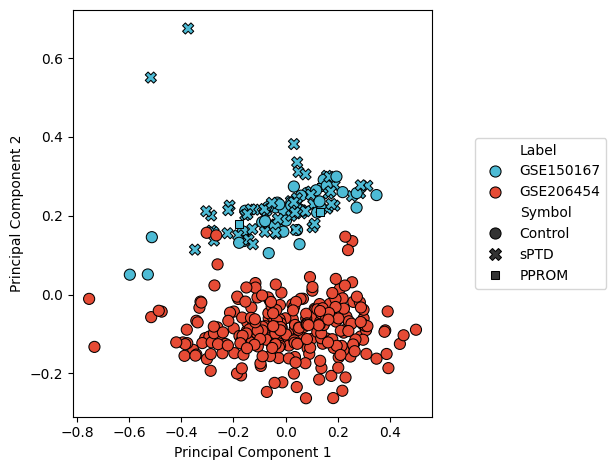

In [ ]:
import seaborn as sns

custom_palette = {
    'GSE206454': '#E64B35FF',
    'GSE150167': '#4DBBD5FF'
}

# seaborn expects categorical columns for grouping
sns.scatterplot(
    x='PC1',
    y='PC2',
    data=scores.assign(Label=labels, Symbol=symbols),
    hue='Label',
    style='Symbol',
    palette = custom_palette,
    s=64,          # marker size
    edgecolor='k', # marker border color
    linewidth=0.75,
)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc = 'center left', bbox_to_anchor=(1.1, 0.5))
plt.tight_layout()
#plt.savefig('../output/tarca_et_al_2021/visuals/seaborn_PCA_plot_second_trimester.png', dpi = 600, bbox_inches = 'tight')
plt.show()

In [ ]:
# 3D scatter plot and data rotation
fig = px.scatter_3d(scores, x = 'PC1', y= 'PC2', z = 'PC3', color = labels, symbol = symbols)
fig.show()

In [ ]:
fig = visualisation.pca_biplot(W, scores, corrected_second_trimester, topN = 20, XPC = 'PC1', YPC = 'PC2')
fig.show()

In [ ]:
feature = 'Fibrinogen' 
fig = visualisation.pca_biplot(W, scores, corrected_second_trimester, topN = 20, XPC = 'PC1', YPC = 'PC2', feature = feature)
fig.show()

# cc_90th DE + constrained: PIM1, UFC1, CPNE1, PPIE?, RAN, DSC3, GPC2, COLEC12, UBE2N
# cc_90th non-DE + constrained: Cyclophilin A, IL-7 Ra, AMNLS, NRP1, FGF-12, Livin B, Arylsulfatase A, STX1a, Flt-3, 6-Phosphogluconate dehydrogenase, Endoglin, IF4A3, IL-17 RC, ULBP-2
# cc_90th non-DE + unconstrained: Fibrinogen

# cc_10th DE + constrained: PCNA, DSC3, GAS1, NR1D1, CNTF, DLL4?, LIN7B, MAPKAPK3?, MEPE?, FSTL3?, GPC2, IL22RA1
# cc_10th non-DE + constrained: Keratin 18, Livin B, GX, FGF-12, IL-10, ENA-78, Galectin-8, b-Endorphin, IL-7 Ra, TAJ, TNF sR-I, Arylsulfatase A, Cyclophilin A, carbonic anhydrase II
# cc_10th non-DE + unconstrained:

# expression different between groups: PKC-B-II, JAK2, Cyclophilin A, P-Selectin, IGFBP-6, Soggy-1, FER, a2-Macroglobulin, Thrombin, PKC-A, STX1a, Cadherin-6, PCSK7

# To be ignored because either problematic or irrelevant
# expression different between groups but highly correlated so potentially problematic: MAPKAPK3 + DEAD-box protein 19B + Integrin a1b1 + GAS1
# cc_90th DE + unconstrained: ACE2
# cc_10th DE + unconstrained: -

In [ ]:
second_trimester

,Accession,Target,Log2RFU,ID_REF,SeqId,TargetFullName,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,GA_delivery,Group,Individual,GEO_accession,Trimester
0,GSM4525301,14-3-3,15.039422,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s132,protein,16.9,40.1,Control,10273,GSE150167,Second trimester
1,GSM4525302,14-3-3,14.625624,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s348,protein,23.0,34.1,sPTD,10877,GSE150167,Second trimester
2,GSM4525303,14-3-3,14.908428,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s226,protein,21.1,36.7,PPROM,10880,GSE150167,Second trimester
3,GSM4525304,14-3-3,15.325044,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s337,protein,20.9,35.0,sPTD,11103,GSE150167,Second trimester
4,GSM4525305,14-3-3,14.627799,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s351,protein,18.7,36.0,sPTD,11170,GSE150167,Second trimester
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408883,GSM6254820,vWF,14.477778,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818822_2,protein,19.6,NaN,Control,9112,GSE206454,Second trimester
408884,GSM6254821,vWF,14.637606,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818670_2,protein,17.4,NaN,Control,11213,GSE206454,Second trimester
408885,GSM6254823,vWF,15.332689,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818822_1,protein,17.4,NaN,Control,11224,GSE206454,Second trimester
408886,GSM6254828,vWF,15.518437,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818631_4,protein,20.6,NaN,Control,14977,GSE206454,Second trimester


In [ ]:
# Save the data for statistical analysis in R
corrected_second_trimester2 = corrected_second_trimester.reset_index()
corrected_second_trimester2
corrected_second_trimester3 = pd.melt(corrected_second_trimester2, id_vars=['Accession', 'GEO_accession', 'Group', 'GA_delivery'], var_name='Target', value_name='Log2RFU')
corrected_second_trimester3

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
0,GSM4525301,GSE150167,Control,40.1,14-3-3,0.844680
1,GSM4525302,GSE150167,sPTD,34.1,14-3-3,0.816994
2,GSM4525303,GSE150167,PPROM,36.7,14-3-3,0.835916
3,GSM4525304,GSE150167,sPTD,35.0,14-3-3,0.863789
4,GSM4525305,GSE150167,sPTD,36.0,14-3-3,0.817140
...,...,...,...,...,...,...
433375,GSM6254820,GSE206454,Control,NaN,vWF,0.989271
433376,GSM6254821,GSE206454,Control,NaN,vWF,1.000121
433377,GSM6254823,GSE206454,Control,NaN,vWF,1.047307
433378,GSM6254828,GSE206454,Control,NaN,vWF,1.059916


In [ ]:
# Export the data
corrected_second_trimester3.to_csv('../output/tarca_et_al_2021/norm_log2t_batch_corrected_integrated_dataset_second_trimester.csv', index = False)

# Third trimester

In [ ]:
stophere 

NameError: name 'stophere' is not defined

In [ ]:
import pandas as pd

In [ ]:
third_trimester = pd.read_csv("../data/tarca-et-al-2021/merged_third_trimester_normalised.csv")
third_trimester

,Accession,Target,Log2RFU,ID_REF,SeqId,TargetFullName,UniProt,EntrezGeneID,EntrezGeneSymbol,Title,Sample_type,GA,GA_delivery,Group,Individual,GEO_accession,Trimester
0,GSM4525406,14-3-3,14.992578,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s55,protein,30.0,40.1,Control,10273,GSE150167,Third trimester
1,GSM4525407,14-3-3,14.833558,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s501,protein,30.4,34.1,sPTD,10877,GSE150167,Third trimester
2,GSM4525408,14-3-3,14.742951,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s238,protein,29.1,36.7,PPROM,10880,GSE150167,Third trimester
3,GSM4525409,14-3-3,15.108780,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s491,protein,28.9,35.0,sPTD,11103,GSE150167,Third trimester
4,GSM4525410,14-3-3,15.020781,SL017611,4179-57_3,14-3-3 protein family,P31946 P62258 P61981 Q04917 P27348 P63104 P31947,7.529753e+28,YWHAB YWHAE YWHAG YWHAH YWHAQ YWHAZ SFN,s504,protein,30.7,36.0,sPTD,11170,GSE150167,Third trimester
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
358789,GSM6254825,vWF,15.102648,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818626_7,protein,29.6,NaN,Control,18763,GSE206454,Third trimester
358790,GSM6254826,vWF,13.763336,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818634_5,protein,40.6,NaN,Control,9093,GSE206454,Third trimester
358791,GSM6254827,vWF,14.342102,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818629_5,protein,27.1,NaN,Control,18090,GSE206454,Third trimester
358792,GSM6254830,vWF,15.277314,SL000017,3050-7,von Willebrand factor,P04275,7.450000e+03,VWF,258633818627_4,protein,29.3,NaN,Control,9900,GSE206454,Third trimester


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import visualisation # some functions defined for this lab
import plotly
import plotly.express as px
import plotly.graph_objs as go

In [ ]:
third_trimester_filtered = third_trimester[['Accession', 'GEO_accession', 'Group', 'GA_delivery', 'Target', 'Log2RFU']]
third_trimester_filtered = third_trimester_filtered.set_index(['Accession', 'GEO_accession', 'Group', 'GA_delivery'])
third_trimester_filtered = third_trimester_filtered.pivot(columns = 'Target', values = 'Log2RFU')
third_trimester_filtered

,,,Target,14-3-3,17-beta-HSD 1,3HIDH,4-1BB,4-1BB ligand,40S ribosomal protein SA,41,4EBP2,6-Phosphogluconate dehydrogenase,6Ckine,...,sRAGE,sRANKL,sTie-1,sTie-2,suPAR,tPA,tau,"transcription factor MLR1, isoform CRA_b",uPA,vWF
Accession,GEO_accession,Group,GA_delivery,,,,,,,,,,,,,,,,,,,,,
GSM4525406,GSE150167,Control,40.1,14.992578,11.406018,9.719100,9.180050,9.143485,11.871923,13.894149,8.329641,14.602722,13.069121,...,8.088585,9.346259,14.613147,11.373415,12.088549,9.363450,10.723321,8.058574,12.574605,14.692756
GSM4525407,GSE150167,sPTD,34.1,14.833558,11.286818,10.147497,8.639090,8.997413,11.888665,13.157231,8.594370,14.282666,13.194531,...,7.802661,9.145019,14.229346,11.859799,13.288067,8.703511,10.451107,7.878898,12.734764,12.645437
GSM4525408,GSE150167,PPROM,36.7,14.742951,11.415764,11.497921,8.534820,8.855695,12.100872,13.430045,8.605532,13.596984,13.347156,...,8.510889,9.309361,14.358423,11.560059,13.203352,9.259577,10.765531,7.814345,12.753611,14.264059
GSM4525409,GSE150167,sPTD,35.0,15.108780,10.872174,9.922614,8.592049,9.022223,11.899606,13.424402,8.735441,13.858329,12.916637,...,8.005933,8.938031,14.316861,11.560304,12.632341,8.761799,10.582568,7.810499,11.539159,13.589266
GSM4525410,GSE150167,sPTD,36.0,15.020781,12.531592,9.757275,8.341050,8.374720,11.602324,14.335198,9.215056,15.278227,13.173382,...,7.858113,8.819057,14.244397,11.199205,11.248939,8.611749,10.563382,7.645639,11.749535,14.929561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM6254825,GSE206454,Control,NaN,NaN,9.445234,9.076227,8.182002,7.785231,9.988425,12.981585,7.713201,12.538324,11.943310,...,10.617573,10.407948,12.927393,10.086558,11.928675,11.813543,9.068229,7.790685,11.427900,15.102648
GSM6254826,GSE206454,Control,NaN,NaN,9.471698,9.544186,8.355273,7.740178,10.831588,12.603849,7.662637,12.969450,12.487946,...,9.495597,9.659248,12.990052,10.072637,11.830702,11.069561,9.144132,7.660245,11.370229,13.763336
GSM6254827,GSE206454,Control,NaN,NaN,9.608149,9.064341,8.185830,7.705137,10.035913,13.327205,7.652550,13.941403,11.908822,...,8.342394,10.440528,13.018324,9.978322,11.064656,11.641999,8.296540,7.596234,11.035111,14.342102


In [ ]:
from combat.pycombat import pycombat
from fancyimpute import SoftImpute
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Normalize the data to reduce technical biases
third_trimester_normalised = third_trimester_filtered.divide(third_trimester_filtered.median(axis=0))

# Step 2: Apply SoftImpute to fill missing values
soft_imputer = SoftImpute(max_iters=100, verbose=True)
third_trim_imputed_array = soft_imputer.fit_transform(third_trimester_normalised.values)

# Step 3: Reconstruct DataFrame
third_trimester_imputed_norm = pd.DataFrame(third_trim_imputed_array, 
                          index=third_trimester_normalised.index,
                          columns=third_trimester_normalised.columns)
third_trimester_imputed_norm

# Step 4: Batch correct
stin = third_trimester_imputed_norm.transpose()
batch = stin.columns.get_level_values('GEO_accession').tolist()
mod_list = stin.columns.get_level_values('Group').tolist()

corrected_df3 = pycombat(stin, batch, mod = mod_list)
corrected_third_trimester = corrected_df3.transpose()

# Step 5: Standardization to normalize the feature variance
scaler = StandardScaler()
X_scaled = scaler.fit_transform(corrected_third_trimester)

c:\Users\doram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\doram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.

c:\Users\doram\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning:

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.



[SoftImpute] Max Singular Value of X_init = 598.103447
[SoftImpute] Iter 1: observed MAE=0.034151 rank=2
[SoftImpute] Iter 2: observed MAE=0.034198 rank=2
[SoftImpute] Iter 3: observed MAE=0.034247 rank=2
[SoftImpute] Iter 4: observed MAE=0.034297 rank=2
[SoftImpute] Iter 5: observed MAE=0.034349 rank=2
[SoftImpute] Iter 6: observed MAE=0.034403 rank=2
[SoftImpute] Iter 7: observed MAE=0.034459 rank=2
[SoftImpute] Iter 8: observed MAE=0.034517 rank=2
[SoftImpute] Iter 9: observed MAE=0.034576 rank=2
[SoftImpute] Iter 10: observed MAE=0.034636 rank=2
[SoftImpute] Iter 11: observed MAE=0.034697 rank=2
[SoftImpute] Iter 12: observed MAE=0.034758 rank=2
[SoftImpute] Iter 13: observed MAE=0.034820 rank=2
[SoftImpute] Iter 14: observed MAE=0.034881 rank=2
[SoftImpute] Iter 15: observed MAE=0.034941 rank=2
[SoftImpute] Iter 16: observed MAE=0.034999 rank=2
[SoftImpute] Iter 17: observed MAE=0.035055 rank=2
[SoftImpute] Iter 18: observed MAE=0.035108 rank=2
[SoftImpute] Iter 19: observed MAE=0

In [ ]:
labels = corrected_third_trimester.index.get_level_values('GEO_accession') # The labels give the group and accession for each protein 
symbols = corrected_third_trimester.index.get_level_values('Group')
N, D = corrected_third_trimester.shape
labels

Index(['GSE150167', 'GSE150167', 'GSE150167', 'GSE150167', 'GSE150167',
       'GSE150167', 'GSE150167', 'GSE150167', 'GSE150167', 'GSE150167',
       ...
       'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454',
       'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454', 'GSE206454'],
      dtype='object', name='GEO_accession', length=326)

In [ ]:
# Running the PCA
W, scores, fracs = visualisation.do_pca(corrected_third_trimester)
# W = factor loading matrix
# scores - PCA scores used to visualise data in a lower dimensional space
# fracs = eigenvalues (normalised to sum to one) give fraction of variance explained by each principal component

# Scale the scores by the maximum value in the score matrix so the plots look better
scores = scores/abs(scores).max().max()

# Add a column with labels for plotting
#scores.index = labels
scores.set_index([labels, symbols])
# scores['label'] = labels

# Factor loading matrix
W
# Each column is a Principal Component (PC)
# Each row gives the "contribution" of each feature to each PC

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20
14-3-3,0.024158,-0.059558,0.036176,0.031581,-0.035405,-0.000717,0.018967,0.019198,-0.023750,0.018385,-0.015769,0.001442,-0.025239,-0.005715,0.034371,0.048068,-0.071583,0.030907,0.010289,0.052806
17-beta-HSD 1,-0.005161,-0.043893,0.000143,0.010709,0.000379,0.005953,0.005213,0.008233,0.021384,-0.042588,0.020299,0.054415,0.053225,0.004871,-0.051916,-0.042574,0.020065,0.007373,0.055585,0.061668
3HIDH,-0.018703,0.001166,0.021945,-0.019089,-0.021910,0.006700,0.019038,-0.010134,-0.009112,0.027487,-0.007366,0.008266,-0.022596,0.033036,-0.006365,0.007104,0.013282,-0.018373,-0.039238,-0.023887
4-1BB,-0.049265,-0.004115,-0.015363,0.017895,-0.010593,0.020983,0.006768,0.002431,-0.014238,-0.008107,0.000209,0.007219,-0.006023,-0.023411,0.003372,-0.010404,-0.001280,-0.023052,0.005290,-0.003888
4-1BB ligand,-0.021298,-0.028715,-0.005260,0.009939,0.006397,-0.014348,-0.041282,0.021599,-0.019676,0.024851,0.086778,0.004682,0.009986,-0.043202,-0.041161,0.041101,0.049087,0.077556,-0.063481,-0.013731
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
tPA,-0.027654,0.017395,0.042504,-0.013405,-0.047201,-0.025649,-0.035043,-0.053123,0.016929,0.021232,0.050426,0.012965,-0.029393,0.002200,0.041329,0.011996,0.045413,0.047724,0.020107,0.003127
tau,-0.001335,-0.022681,0.008329,-0.022855,-0.046757,-0.032049,-0.006754,-0.019130,-0.000262,0.008354,-0.038324,-0.031610,0.075421,-0.035522,0.016761,-0.030344,-0.016431,0.045485,-0.042052,-0.034589
"transcription factor MLR1, isoform CRA_b",-0.040851,-0.028824,0.000586,-0.001845,-0.007732,0.017538,-0.018930,0.004839,-0.050906,-0.031203,-0.011358,0.014033,0.019293,-0.019456,-0.025158,-0.004619,0.012266,0.004022,0.041985,-0.009216
uPA,-0.043698,-0.001176,0.020991,0.027497,-0.022360,-0.042533,0.010351,-0.017033,0.015456,-0.009047,0.025873,-0.070604,-0.024052,-0.024691,-0.033525,0.018612,0.020382,0.011074,0.007646,-0.030497


In [ ]:
W.to_csv('../hypergraph/data/tarca_et_al_2021/PCA_W3.csv')
scores.to_csv('../hypergraph/data/tarca_et_al_2021/PCA_scores3.csv')

In [ ]:
# Create a numpy array from 1 up to the length of the fracs vector
x = np.arange(1, len(fracs) + 1)

# Put the fracs into a numpy array
y = np.array(fracs)

# Plotting the variance explained by each principal component
fig = go.Figure(data = go.Scatter(x = x, y = y))
fig.update_layout(xaxis_title = 'Principal component', 
                  yaxis_title = 'Variance explained (fraction)', 
                  xaxis = dict(dtick = 1.0)) 
fig.show()

In [ ]:
# Create a cumulative sum of elements in the fracs array
x = np.arange(1, len(fracs) + 1)
y = np.cumsum(fracs) 

# Plotting the variance explained by cumulative proportion
fig = go.Figure(data = go.Scatter(x = x, y = y))
fig.update_layout(xaxis_title = 'Principal component', 
                  yaxis_title = 'Variance explained (cumulative)', 
                  xaxis = dict(dtick = 1.0))
fig.show()

In [ ]:
# 2D scatter plot of the scores
XPC = 'PC1' # Principal component shown on x-axis
YPC = 'PC2' # Principal component shown on y-axis
fig = px.scatter(scores, x = XPC, y = YPC, color = labels, symbol = symbols, hover_data = [XPC, YPC])
fig.update_traces(mode = 'markers', marker_line_width = 1, marker_size = 8)
fig.show()

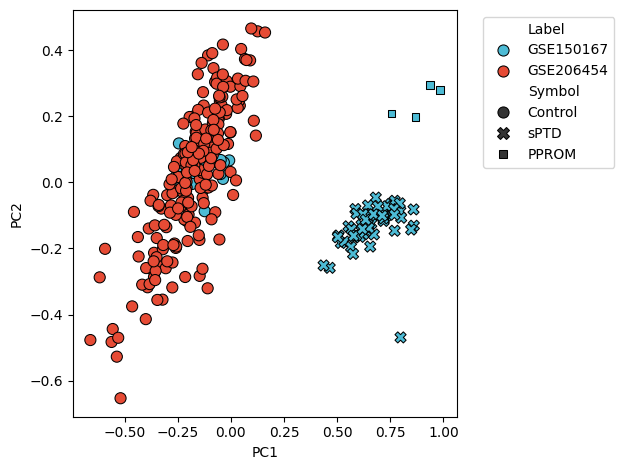

In [ ]:
import seaborn as sns

custom_palette = {
    'GSE206454': '#E64B35FF',
    'GSE150167': '#4DBBD5FF'
}

# seaborn expects categorical columns for grouping
sns.scatterplot(
    x='PC1',
    y='PC2',
    data=scores.assign(Label=labels, Symbol=symbols),
    hue='Label',
    style='Symbol',
    palette = custom_palette,
    s=64,          # marker size
    edgecolor='k', # marker border color
    linewidth=0.75,
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.savefig('../output/tarca_et_al_2021/visuals/seaborn_PCA_plot_third_trimester.png', dpi = 600, bbox_inches = 'tight')
plt.show()

In [ ]:
# 3D scatter plot and data rotation
fig = px.scatter_3d(scores, x = 'PC1', y= 'PC2', z = 'PC3', color = labels, symbol = symbols)
fig.show()

In [ ]:
fig = visualisation.pca_biplot(W, scores, corrected_third_trimester, topN = 20, XPC = 'PC1', YPC = 'PC2')
fig.show()

TypeError: Argument 'color' is a pandas MultiIndex. pandas MultiIndex is not supported by plotly express at the moment.

In [ ]:
feature = 'JAK2' 
fig = visualisation.pca_biplot(W, scores, corrected_third_trimester, topN = 20, XPC = 'PC1', YPC = 'PC2', feature = feature)
fig.show()

# differentially expressed: STX1a, DEAD-box protein 19B, IL-4?, HSP 90a/b?

In [ ]:
# Save the data for statistical analysis in R
corrected_third_trimester2 = corrected_third_trimester.reset_index()
corrected_third_trimester2
corrected_third_trimester3 = pd.melt(corrected_third_trimester2, id_vars=['Accession', 'GEO_accession', 'Group', 'GA_delivery'], var_name='Target', value_name='Log2RFU')
corrected_third_trimester3

,Accession,GEO_accession,Group,GA_delivery,Target,Log2RFU
0,GSM4525406,GSE150167,Control,40.1,14-3-3,0.854517
1,GSM4525407,GSE150167,sPTD,34.1,14-3-3,0.853892
2,GSM4525408,GSE150167,PPROM,36.7,14-3-3,0.853894
3,GSM4525409,GSE150167,sPTD,35.0,14-3-3,0.865530
4,GSM4525410,GSE150167,sPTD,36.0,14-3-3,0.861809
...,...,...,...,...,...,...
379785,GSM6254825,GSE206454,Control,NaN,vWF,1.000289
379786,GSM6254826,GSE206454,Control,NaN,vWF,0.982881
379787,GSM6254827,GSE206454,Control,NaN,vWF,0.990403
379788,GSM6254830,GSE206454,Control,NaN,vWF,1.002559


In [ ]:
corrected_third_trimester3.to_csv('../output/tarca_et_al_2021/norm_log2t_batch_corrected_integrated_dataset_third_trimester.csv', index = False)